# Exercises - Naive Bays

1. Smoothing experiment. Train MultinomialNB on text data with alpha values of 0.01, 0.1, 1.0, 10.0, and 100.0. Plot accuracy vs alpha. Where does performance peak? Why does very high alpha hurt?
2. Feature independence test. Take a real text dataset. Pick two words that are obviously correlated ("machine" and "learning"). Compute P(word1 | class) * P(word2 | class) and compare to P(word1 AND word2 | class). How wrong is the independence assumption? Does it affect classification accuracy?
3. Bernoulli implementation. Extend the code with a BernoulliNB class. Convert bag-of-words to binary (present/absent) and compare accuracy against MultinomialNB on text data. When does Bernoulli win?
4. NB vs Logistic Regression. Train both on text data. Start with 100 training samples and increase to 10,000. Plot accuracy vs training set size for both. At what point does Logistic Regression overtake Naive Bayes?
5. Spam filter. Build a complete spam classifier: tokenize raw email text, build vocabulary, create bag-of-words features, train MultinomialNB, evaluate with precision and recall (not just accuracy -- why?). ```Would Be A Sexy Project```


### 1. Smoothing experiment. Train MultinomialNB on text data with alpha values of 0.01, 0.1, 1.0, 10.0, and 100.0. Plot accuracy vs alpha. Where does performance peak? Why does very high alpha hurt?

In [64]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [65]:
news = fetch_20newsgroups()

In [66]:
X = news["data"]
y = news["target"]

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25)

In [68]:
vectorizer = TfidfVectorizer()


In [69]:
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [70]:
alpha_values = [0.01,0.1,1.0,10.0,100.0]
iterations =   [1,2,3,4,5]

In [71]:
accuracy_scores=[]
iteration = 0
for alpha_v in alpha_values:
    model = MultinomialNB(alpha=alpha_v)
    print("==========================================================================")
    
    print(f"Trainig Started For Iteration {iteration} - For Alpha : {alpha_v}")
    model.fit(X_train,y_train)
    score = model.score(X_test,y_test)
    accuracy_scores.append(score)
    
    print(f"Accuracy Score For Iteration {iteration} - For Alpha : {alpha_v} - ACcuracy Score : {score}")
    print("==========================================================================")
    print("\n")
    iteration+=1
    
    

Trainig Started For Iteration 0 - For Alpha : 0.01
Accuracy Score For Iteration 0 - For Alpha : 0.01 - ACcuracy Score : 0.9109225874867445


Trainig Started For Iteration 1 - For Alpha : 0.1
Accuracy Score For Iteration 1 - For Alpha : 0.1 - ACcuracy Score : 0.8985507246376812


Trainig Started For Iteration 2 - For Alpha : 1.0
Accuracy Score For Iteration 2 - For Alpha : 1.0 - ACcuracy Score : 0.8430540827147401


Trainig Started For Iteration 3 - For Alpha : 10.0
Accuracy Score For Iteration 3 - For Alpha : 10.0 - ACcuracy Score : 0.6677271120537293


Trainig Started For Iteration 4 - For Alpha : 100.0
Accuracy Score For Iteration 4 - For Alpha : 100.0 - ACcuracy Score : 0.38494167550371156




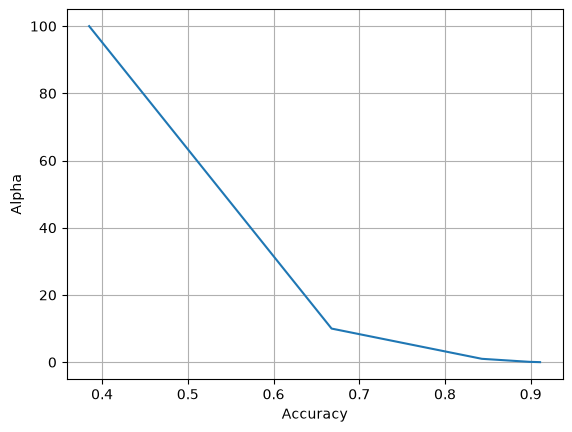

In [72]:
# plotting the accuracy vs iteration
import matplotlib.pyplot as plt
plt.plot(accuracy_scores,alpha_values)
plt.xlabel("Accuracy")
plt.ylabel("Alpha")
plt.grid()

### 02. 

### 03.

### 04. NB vs Logistic Regression. Train both on text data. Start with 100 training samples and increase to 10,000. Plot accuracy vs training set size for both. At what point does Logistic Regression overtake Naive Bayes?

In [73]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [58]:
news = fetch_20newsgroups()
X = news["data"]
y = news["target"]

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25)

In [60]:
vectorizer = TfidfVectorizer()

In [61]:
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [62]:

iteration = 0
for alpha_v in alpha_values:
    model = MultinomialNB(alpha=alpha_v)
    print("==========================================================================")
    
    print(f"Trainig Started For Iteration {iteration} - For Alpha : {alpha_v}")
    model.fit(X_train,y_train)
    score = model.score(X_test,y_test)
    accuracy_scores.append(score)
    
    print(f"Accuracy Score For Iteration {iteration} - For Alpha : {alpha_v} - ACcuracy Score : {score}")
    print("==========================================================================")
    print("\n")
    iteration+=1
    
    

Trainig Started For Iteration 0 - For Alpha : 0.01
Accuracy Score For Iteration 0 - For Alpha : 0.01 - ACcuracy Score : 0.9063273241428067


Trainig Started For Iteration 0 - For Alpha : 0.1
Accuracy Score For Iteration 0 - For Alpha : 0.1 - ACcuracy Score : 0.8900671615411806


Trainig Started For Iteration 0 - For Alpha : 1.0
Accuracy Score For Iteration 0 - For Alpha : 1.0 - ACcuracy Score : 0.8066454577589254


Trainig Started For Iteration 0 - For Alpha : 10.0
Accuracy Score For Iteration 0 - For Alpha : 10.0 - ACcuracy Score : 0.6026864616472252


Trainig Started For Iteration 0 - For Alpha : 100.0
Accuracy Score For Iteration 0 - For Alpha : 100.0 - ACcuracy Score : 0.24036762106751502




In [63]:
iteration=0

training_set_size=[]
accuracy_lg=[]
accuracy_mnb=[]


for i in range(100,10100,1000):
    training_set_size.append(i)
    # steeping by 100 data points 
    
    print("==========================================================================")
    
    print(f"Trainig Started For Iteration {iteration} - For Trainig Size : {i}")
    
    model_mnb = MultinomialNB(alpha=0.01)
    model_mnb.fit(X_train[:i],y_train[:i])
    score_mnb = model_mnb.score(X_test,y_test)
    accuracy_mnb.append(score_mnb)

    model_lg=LogisticRegression()
    model_lg.fit(X_train[:i],y_train[:i])
    score_lg = model_lg.score(X_test,y_test)
    accuracy_lg.append(score_lg)

    
    print(f"Trainig End For Iteration {iteration} - For Trainig Size : {i} - Score For Multinomial Naive Bays : {score_mnb}")
    print(f"Trainig End For Iteration {iteration} - For Trainig Size : {i} - Score For Multinomial Logistic Regression  : {score_lg}")
    print("==========================================================================")
    print("\n")
    iteration+=1
    

Trainig Started For Iteration 0 - For Trainig Size : 100
Trainig End For Iteration 0 - For Trainig Size : 100 - Score For Multinomial Naive Bays : 0.2979851537645811
Trainig End For Iteration 0 - For Trainig Size : 100 - Score For Multinomial Logistic Regression  : 0.19123365146694946


Trainig Started For Iteration 1 - For Trainig Size : 1100
Trainig End For Iteration 1 - For Trainig Size : 1100 - Score For Multinomial Naive Bays : 0.72039589961117
Trainig End For Iteration 1 - For Trainig Size : 1100 - Score For Multinomial Logistic Regression  : 0.664192294096854


Trainig Started For Iteration 2 - For Trainig Size : 2100
Trainig End For Iteration 2 - For Trainig Size : 2100 - Score For Multinomial Naive Bays : 0.8031106398020502
Trainig End For Iteration 2 - For Trainig Size : 2100 - Score For Multinomial Logistic Regression  : 0.7730646871686108


Trainig Started For Iteration 3 - For Trainig Size : 3100
Trainig End For Iteration 3 - For Trainig Size : 3100 - Score For Multinomial

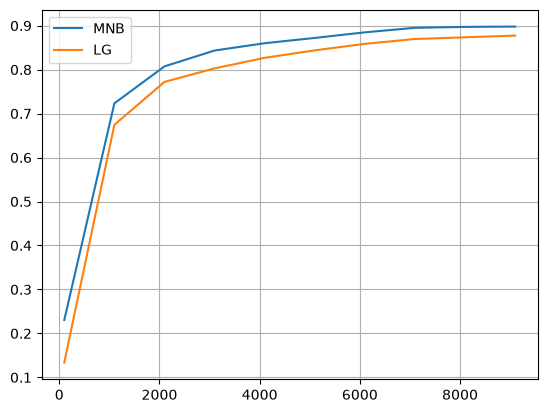

In [53]:
plt.plot(training_set_size,accuracy_mnb,label="MNB")
plt.plot(training_set_size,accuracy_lg,label="LG")
plt.legend()
plt.grid()

**from chatgpt**

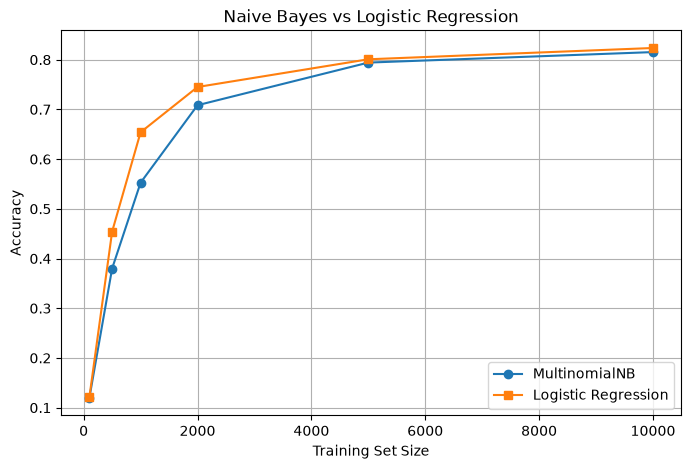

In [54]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load data
train = fetch_20newsgroups(subset="train")
test = fetch_20newsgroups(subset="test")

# TF-IDF features
vectorizer = TfidfVectorizer(stop_words="english", max_features=20000)

X_train = vectorizer.fit_transform(train.data)
X_test = vectorizer.transform(test.data)

y_train = np.array(train.target)
y_test = np.array(test.target)

sizes = [100, 500, 1000, 2000, 5000, 10000]

nb_acc = []
lr_acc = []

for size in sizes:
    X = X_train[:size]
    y = y_train[:size]

    # Naive Bayes
    nb = MultinomialNB()
    nb.fit(X, y)
    nb_acc.append(accuracy_score(y_test, nb.predict(X_test)))

    # Logistic Regression
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X, y)
    lr_acc.append(accuracy_score(y_test, lr.predict(X_test)))

# Plot
plt.figure(figsize=(8,5))
plt.plot(sizes, nb_acc, marker='o', label='MultinomialNB')
plt.plot(sizes, lr_acc, marker='s', label='Logistic Regression')

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Naive Bayes vs Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

### 05. Spam filter. Build a complete spam classifier: tokenize raw email text, build vocabulary, create bag-of-words features, train MultinomialNB, evaluate with precision and recall (not just accuracy -- why?). Would Be A Sexy Project

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Vocabulary Size: 7440

Accuracy : 0.9839
Precision: 0.958
Recall   : 0.9195
F1 Score : 0.9384

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.96      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



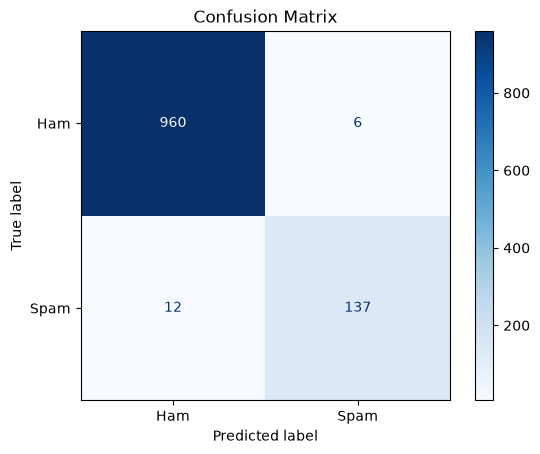


Custom Predictions

Spam: Congratulations! You have won a free iPhone. Click here now.
Ham: Can we meet tomorrow at 10 AM?
Spam: URGENT! Claim your cash prize now.
Ham: Please send me the assignment before evening.


In [55]:
# ==============================
# Spam Filter using MultinomialNB
# ==============================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# -------------------------------
# Load Dataset
# -------------------------------

df = pd.read_csv("spam.csv", encoding="latin-1")

# Keep only useful columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(df.head())

# -------------------------------
# Convert labels
# ham = 0
# spam = 1
# -------------------------------

df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

# -------------------------------
# Split Data
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    df['message'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

# -------------------------------
# Bag of Words
# -------------------------------

vectorizer = CountVectorizer(
    stop_words='english'
)

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

print("Vocabulary Size:", len(vectorizer.vocabulary_))

# -------------------------------
# Train Multinomial Naive Bayes
# -------------------------------

model = MultinomialNB()

model.fit(X_train, y_train)

# -------------------------------
# Prediction
# -------------------------------

y_pred = model.predict(X_test)

# -------------------------------
# Evaluation
# -------------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nAccuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

# -------------------------------
# Confusion Matrix
# -------------------------------

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# -------------------------------
# Test on Custom Emails
# -------------------------------

emails = [
    "Congratulations! You have won a free iPhone. Click here now.",
    "Can we meet tomorrow at 10 AM?",
    "URGENT! Claim your cash prize now.",
    "Please send me the assignment before evening."
]

features = vectorizer.transform(emails)

predictions = model.predict(features)

print("\nCustom Predictions\n")

for email, pred in zip(emails, predictions):
    label = "Spam" if pred == 1 else "Ham"
    print(f"{label}: {email}")